This time, we focus on a small set of papers from 2021-- and draw the figures needed for the paper.

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

In [19]:
CAMBRIDGE_COLORS = {
    # Core palette
    "cambridge_blue": "#8EE8D8",
    "cambridge_light_blue": "#D1F9F1",
    "cambridge_warm_blue": "#00BDB6",
    "cambridge_dark_blue": "#133844",
    # Crest series
    "light_crest": "#FFE2C8",
    "warm_crest": "#FFC392",
    "crest": "#FD8153",
    "dark_crest": "#DD3025",
    # Cherry series
    "light_cherry": "#F2CAD8",
    "warm_cherry": "#E18AAC",
    "cherry": "#CD3572",
    "dark_cherry": "#911449",
    # Purple series
    "light_purple": "#F2ECF8",
    "warm_purple": "#D1B7EB",
    "purple": "#A368DF",
    "dark_purple": "#681FB1",
    # Indigo series
    "light_indigo": "#EBEDFB",
    "warm_indigo": "#B0B9F1",
    "indigo": "#5366E0",
    "dark_indigo": "#29347A",
    # Green series
    "light_green": "#DFF2EA",
    "warm_green": "#AFDFCB",
    "green": "#4DB78C",
    "dark_green": "#13553A",
    # Greyscale
    "white": "#FFFFFF",
    "slate_1": "#ECEEF1",
    "slate_2": "#B5BDC8",
    "slate_3": "#546072",
    "slate_4": "#232830",
    # Heritage & special
    "heritage_blue": "#85B09A",
    "judge_yellow": "#ffb81c",
}

# Use TeX fonts with Times New Roman
plt.rcParams.update(
    {
        "text.usetex": True,
        "text.latex.preamble": r"\usepackage{mathptmx}",  # Times font for math and text
        "font.family": "serif",
        "font.serif": ["Times"],
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "legend.fontsize": 12,
        "font.size": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
    }
)

In [20]:
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./outputs/2026-02-12-figures-for-paper")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

In [21]:
df = pd.read_csv(DATA_DIR / "interventions_dataset.csv")

## Tokenizer Fertility vs Common Crawl Percentage

In [ ]:
# Load language resourceness data
lang_df = pd.read_csv(DATA_DIR / "tokenizer_fertility" / "language_resourceness.csv")

# Load tokenizer fertility data for each model
fertility_dir = DATA_DIR / "tokenizer_fertility"
model_files = [
    f for f in fertility_dir.glob("*.csv") if f.name != "language_resourceness.csv"
]

# Create a combined dataframe with all models
fertility_dfs = []
for model_file in model_files:
    model_name = model_file.stem.replace("___", "/")
    model_df = pd.read_csv(model_file)
    model_df["model"] = model_name
    fertility_dfs.append(model_df)

fertility_df = pd.concat(fertility_dfs, ignore_index=True)

# Merge with language data
merged_df = fertility_df.merge(lang_df, on="subset", how="left")

# Remove languages not in Common Crawl
merged_df = merged_df[merged_df["commoncrawl_percentage"] > 0]

# Extract script from subset (e.g., "eng_Latn" -> "Latn")
merged_df["script"] = merged_df["subset"].str.extract(r"_([A-Za-z]+)")

# Filter to Latin-script languages only
merged_df = merged_df[merged_df["script"] == "Latn"]

# Remove outliers: filter out languages with fertility > 95th percentile
tpw_95 = merged_df["tpw"].quantile(0.95)
merged_df = merged_df[merged_df["tpw"] <= tpw_95]

print(
    f"Languages after filtering (Latin-script, no outliers): {merged_df['subset'].nunique()}"
)
print(f"Language families: {merged_df['lang_family'].nunique()}")
print(f"\nLanguages per resource level:")
print(merged_df.groupby("lang2tax")["subset"].nunique())

Languages after filtering (Latin-script, no outliers): 83
Language families: 13

Languages per resource level:
lang2tax
0     4
1    35
2    11
3    15
4    13
5     5
Name: subset, dtype: int64


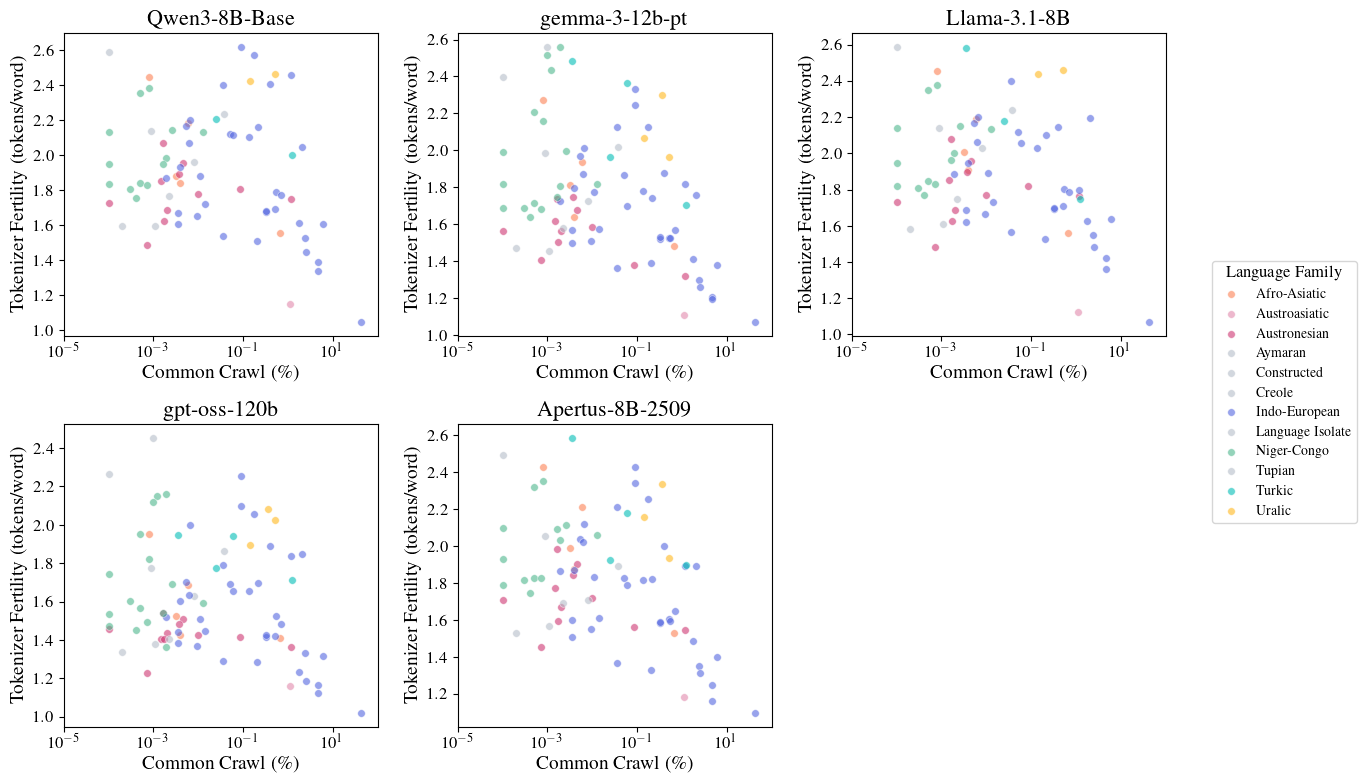

In [23]:
# Get unique models and language families
models = sorted(merged_df["model"].unique())
lang_families = sorted(merged_df["lang_family"].dropna().unique())

# Create a color palette for language families
family_colors = {
    "Indo-European": CAMBRIDGE_COLORS["indigo"],
    "Afro-Asiatic": CAMBRIDGE_COLORS["crest"],
    "Niger-Congo": CAMBRIDGE_COLORS["green"],
    "Austronesian": CAMBRIDGE_COLORS["cherry"],
    "Sino-Tibetan": CAMBRIDGE_COLORS["purple"],
    "Turkic": CAMBRIDGE_COLORS["cambridge_warm_blue"],
    "Uralic": CAMBRIDGE_COLORS["judge_yellow"],
    "Dravidian": CAMBRIDGE_COLORS["dark_crest"],
    "Austroasiatic": CAMBRIDGE_COLORS["warm_cherry"],
    "Tai-Kadai": CAMBRIDGE_COLORS["warm_purple"],
}
# Default color for other families
default_color = CAMBRIDGE_COLORS["slate_2"]

# Create faceted scatter plot
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows), squeeze=False)
axes = axes.flatten()

for idx, model in enumerate(models):
    ax = axes[idx]
    model_data = merged_df[merged_df["model"] == model]

    # Plot each language family
    for family in lang_families:
        family_data = model_data[model_data["lang_family"] == family]
        if len(family_data) > 0:
            color = family_colors.get(family, default_color)
            ax.scatter(
                family_data["commoncrawl_percentage"],
                family_data["tpw"],
                c=color,
                label=family if idx == 0 else "",
                alpha=0.6,
                s=30,
                edgecolors="white",
                linewidths=0.5,
            )

    ax.set_xlabel("Common Crawl (\%)")
    ax.set_ylabel("Tokenizer Fertility (tokens/word)")
    ax.set_title(model.split("/")[-1])
    ax.set_xscale("log")
    ax.set_xlim(1e-5, 100)

# Hide empty subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

# Add legend to the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center right",
    bbox_to_anchor=(1.15, 0.5),
    title="Language Family",
    fontsize=10,
)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "tokenizer_fertility_vs_cc.pdf", bbox_inches="tight", dpi=300)
plt.show()

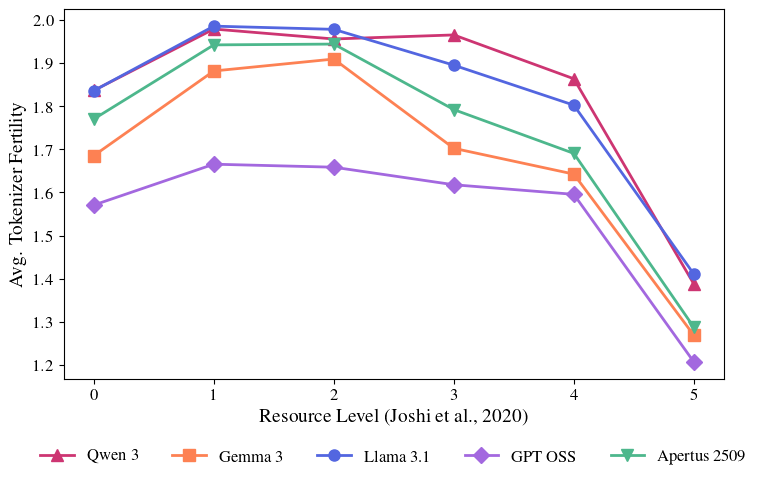

In [34]:
# Compute average tpw per model and lang2tax level
avg_fertility = merged_df.groupby(["model", "lang2tax"])["tpw"].mean().reset_index()

# Create color, marker, and display name for models
model_styles = {
    "meta-llama/Llama-3.1-8B": {
        "color": CAMBRIDGE_COLORS["indigo"],
        "marker": "o",
        "name": "Llama 3.1",
    },
    "google/gemma-3-12b-pt": {
        "color": CAMBRIDGE_COLORS["crest"],
        "marker": "s",
        "name": "Gemma 3",
    },
    "Qwen/Qwen3-8B-Base": {
        "color": CAMBRIDGE_COLORS["cherry"],
        "marker": "^",
        "name": "Qwen 3",
    },
    "openai/gpt-oss-120b": {
        "color": CAMBRIDGE_COLORS["purple"],
        "marker": "D",
        "name": "GPT OSS",
    },
    "swiss-ai/Apertus-8B-2509": {
        "color": CAMBRIDGE_COLORS["green"],
        "marker": "v",
        "name": "Apertus 2509",
    },
}

fig, ax = plt.subplots(figsize=(8, 5))

for model in sorted(avg_fertility["model"].unique()):
    model_data = avg_fertility[avg_fertility["model"] == model].sort_values("lang2tax")
    style = model_styles.get(
        model, {"color": CAMBRIDGE_COLORS["slate_3"], "marker": "o", "name": model}
    )
    ax.plot(
        model_data["lang2tax"],
        model_data["tpw"],
        marker=style["marker"],
        linewidth=2,
        markersize=8,
        label=style["name"],
        color=style["color"],
    )

ax.set_xlabel("Resource Level (Joshi et al., 2020)")
ax.set_ylabel("Avg. Tokenizer Fertility")
ax.set_xticks(range(6))

# Legend below x-axis, 5 columns
ax.legend(
    #    title="Tokenizer",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=5,
    frameon=False,
)

fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "tokenizer_fertility_by_resource_level.pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()